# 06 · Comparaison des approches

**Ce que fait ce notebook.** Il rassemble les six approches mesurées dans les notebooks précédents et
répond à la seule question qui compte pour une décision : **quoi mettre en production, et pourquoi.**

Il ne recalcule rien. Il lit les artefacts produits par `benchmark.py`, qui applique le protocole
identique à toutes les approches — c'est ce qui rend les chiffres comparables entre eux.

In [1]:
import sys
from pathlib import Path

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 40)

SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, BLEU_CLAIR, BLEU_FONCE, GRILLE = "#2a78d6", "#cde2fb", "#0d366b", "#e0dfdb"
VERT, ROUGE = "#0ca30c", "#d03b3b"
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "font.size": 11,
        "text.color": ENCRE,
        "axes.labelcolor": ENCRE_2,
        "axes.edgecolor": GRILLE,
        "xtick.color": ENCRE_2,
        "ytick.color": ENCRE_2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

from src.evaluate import SEUIL_F1_METIER
from src.pipeline import LABEL_COL, SEED, TEXT_COL, load, split

df = load()
train, val, test = split(df)
CATEGORIES = sorted(df[LABEL_COL].unique())
print(f"train {len(train)} · val {len(val)} · test {len(test)}")
print(f"seuil métier : F1 macro >= {SEUIL_F1_METIER:.2f}, fixé avant toute mesure")

train 735 · val 157 · test 158
seuil métier : F1 macro >= 0.90, fixé avant toute mesure


In [2]:
RAPPORTS = RACINE / "reports"
tableau = pd.read_csv(RAPPORTS / "benchmark.csv")
tableau

,Modèle,F1 macro,Accuracy,F1 classe min,Entraînement (s),Inférence (ms/article),Empreinte (Mo),"Seuil 0,90"
0,Fusion texte + image,0.9744,0.9747,0.9545,1.86,35.75,365.4,oui
1,TF-IDF + MLP,0.9427,0.9430,0.8696,0.51,0.06,14.3,oui
2,DINOv2 figé — image seule,0.9366,0.9367,0.8636,0.17,35.70,346.3,oui
3,BERT figé (2018),0.9243,0.9241,0.8696,16.79,22.02,437.9,oui
4,TF-IDF + XGBoost,0.9234,0.9241,0.8372,4.61,0.08,2.6,oui
5,ModernBERT figé (2024),0.8854,0.8861,0.8000,29.10,38.89,596.1,non


## 1 · Le seuil métier ne départage rien — et c'est le résultat

Le seuil a été fixé **avant** toute mesure : F1 macro ≥ 0,90. C'est une exigence de méthode, pas une
formalité. Une tolérance dérivée du résultat obtenu placerait le modèle à la limite d'acceptation par
construction.

In [3]:
franchissent = (tableau["Seuil 0,90"] == "oui").sum()
print(f"{franchissent} approches sur {len(tableau)} franchissent le seuil métier\n")
print(tableau[["Modèle", "F1 macro", "Seuil 0,90"]].to_string(index=False))

ecart_f1 = tableau["F1 macro"].max() - tableau["F1 macro"].min()
ecart_inf = tableau["Inférence (ms/article)"].max() / tableau["Inférence (ms/article)"].min()
print(f"\namplitude de la performance : {ecart_f1:.3f} point de F1")
print(f"amplitude du coût d'inférence : facteur {ecart_inf:.0f}")

5 approches sur 6 franchissent le seuil métier

                   Modèle  F1 macro Seuil 0,90
     Fusion texte + image    0.9744        oui
             TF-IDF + MLP    0.9427        oui
DINOv2 figé — image seule    0.9366        oui
         BERT figé (2018)    0.9243        oui
         TF-IDF + XGBoost    0.9234        oui
   ModernBERT figé (2024)    0.8854        non

amplitude de la performance : 0.089 point de F1
amplitude du coût d'inférence : facteur 648


**Voilà l'argument central du projet.** Cinq approches sur six franchissent le seuil métier :
la performance les sépare de moins de 9 centièmes de F1, alors que leur coût d'inférence varie d'un
facteur de plusieurs centaines.

**La performance ne permet donc pas de choisir. Le coût, si.** C'est ce qui transforme un classement
en décision.

## 2 · Performance contre coût

→ reports/fig1_cout.png


→ reports/fig2_f1_par_classe.png


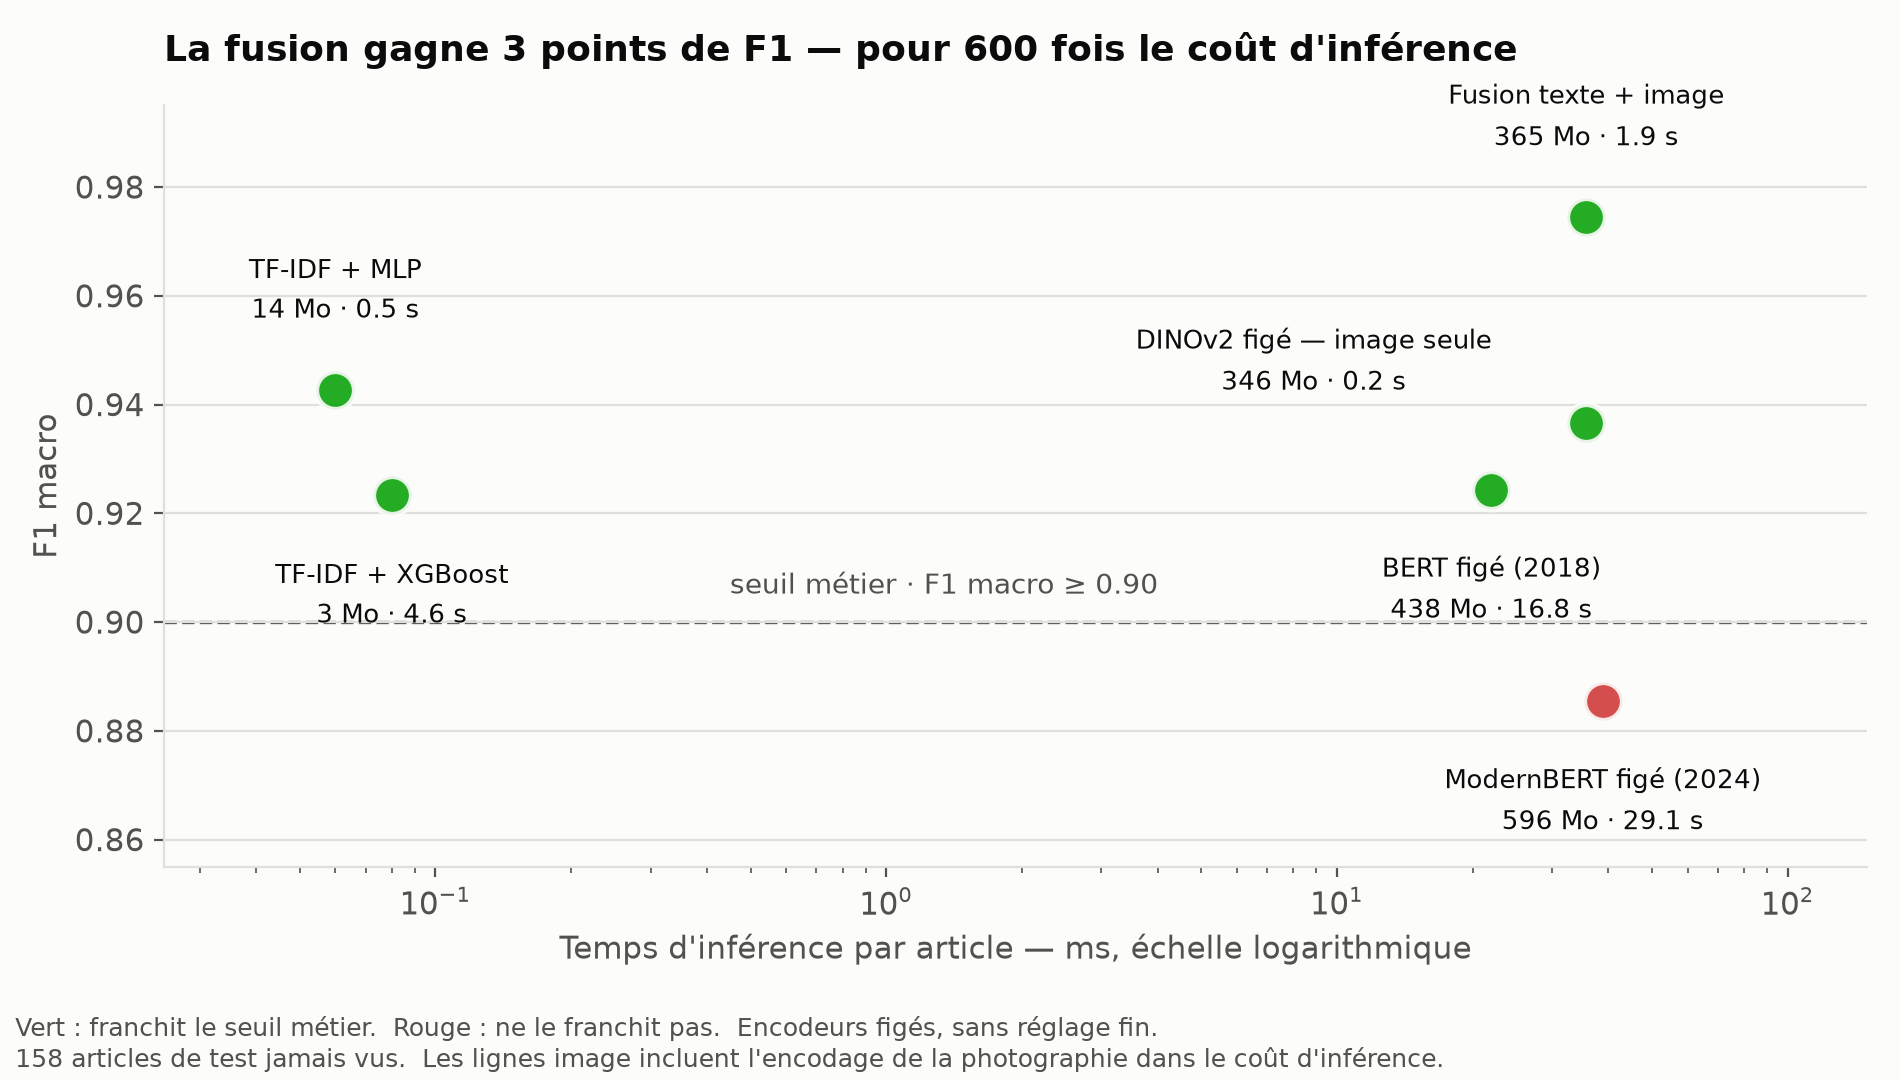

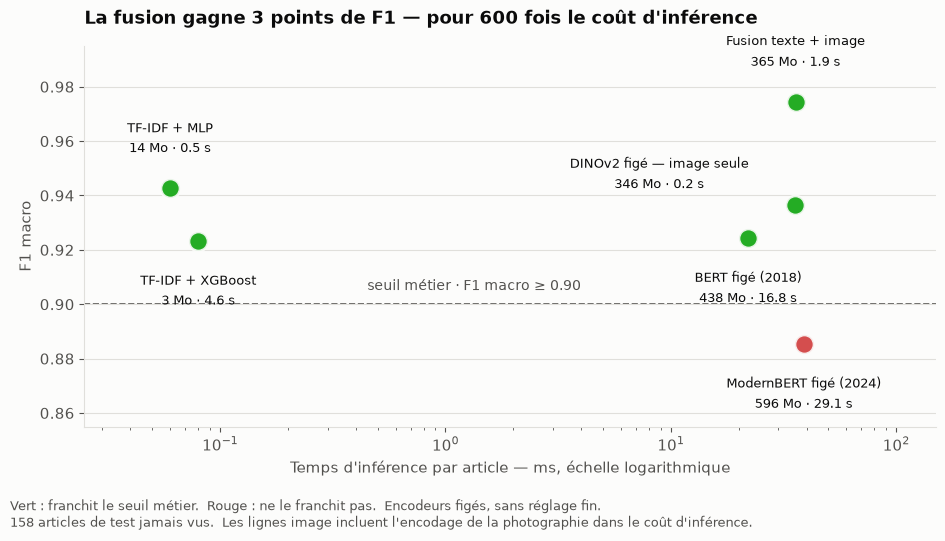

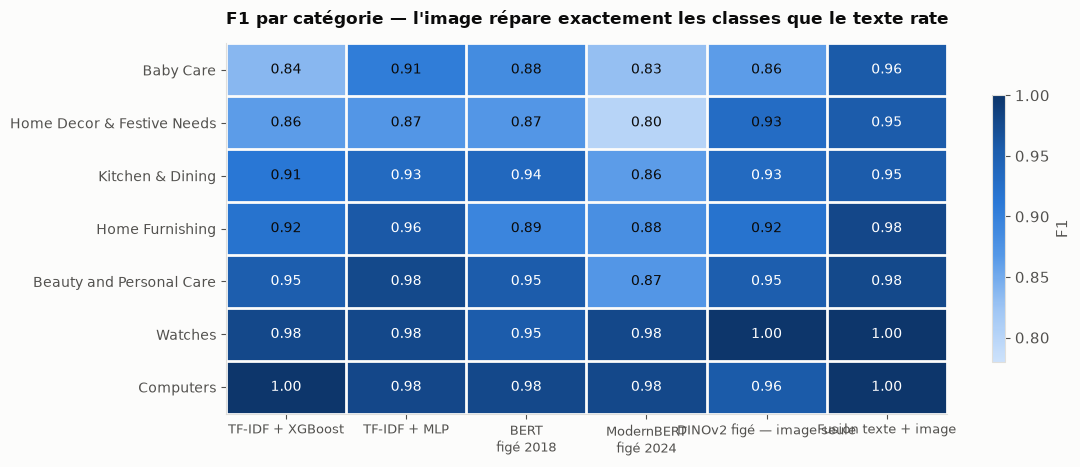

In [4]:
from src.figures import fig1, fig2
import json

fig1(tableau)
fig2(json.loads((RAPPORTS / "f1_par_classe.json").read_text(encoding="utf-8")))
from IPython.display import Image as Img, display

display(Img(str(RAPPORTS / "fig1_cout.png"), width=980))

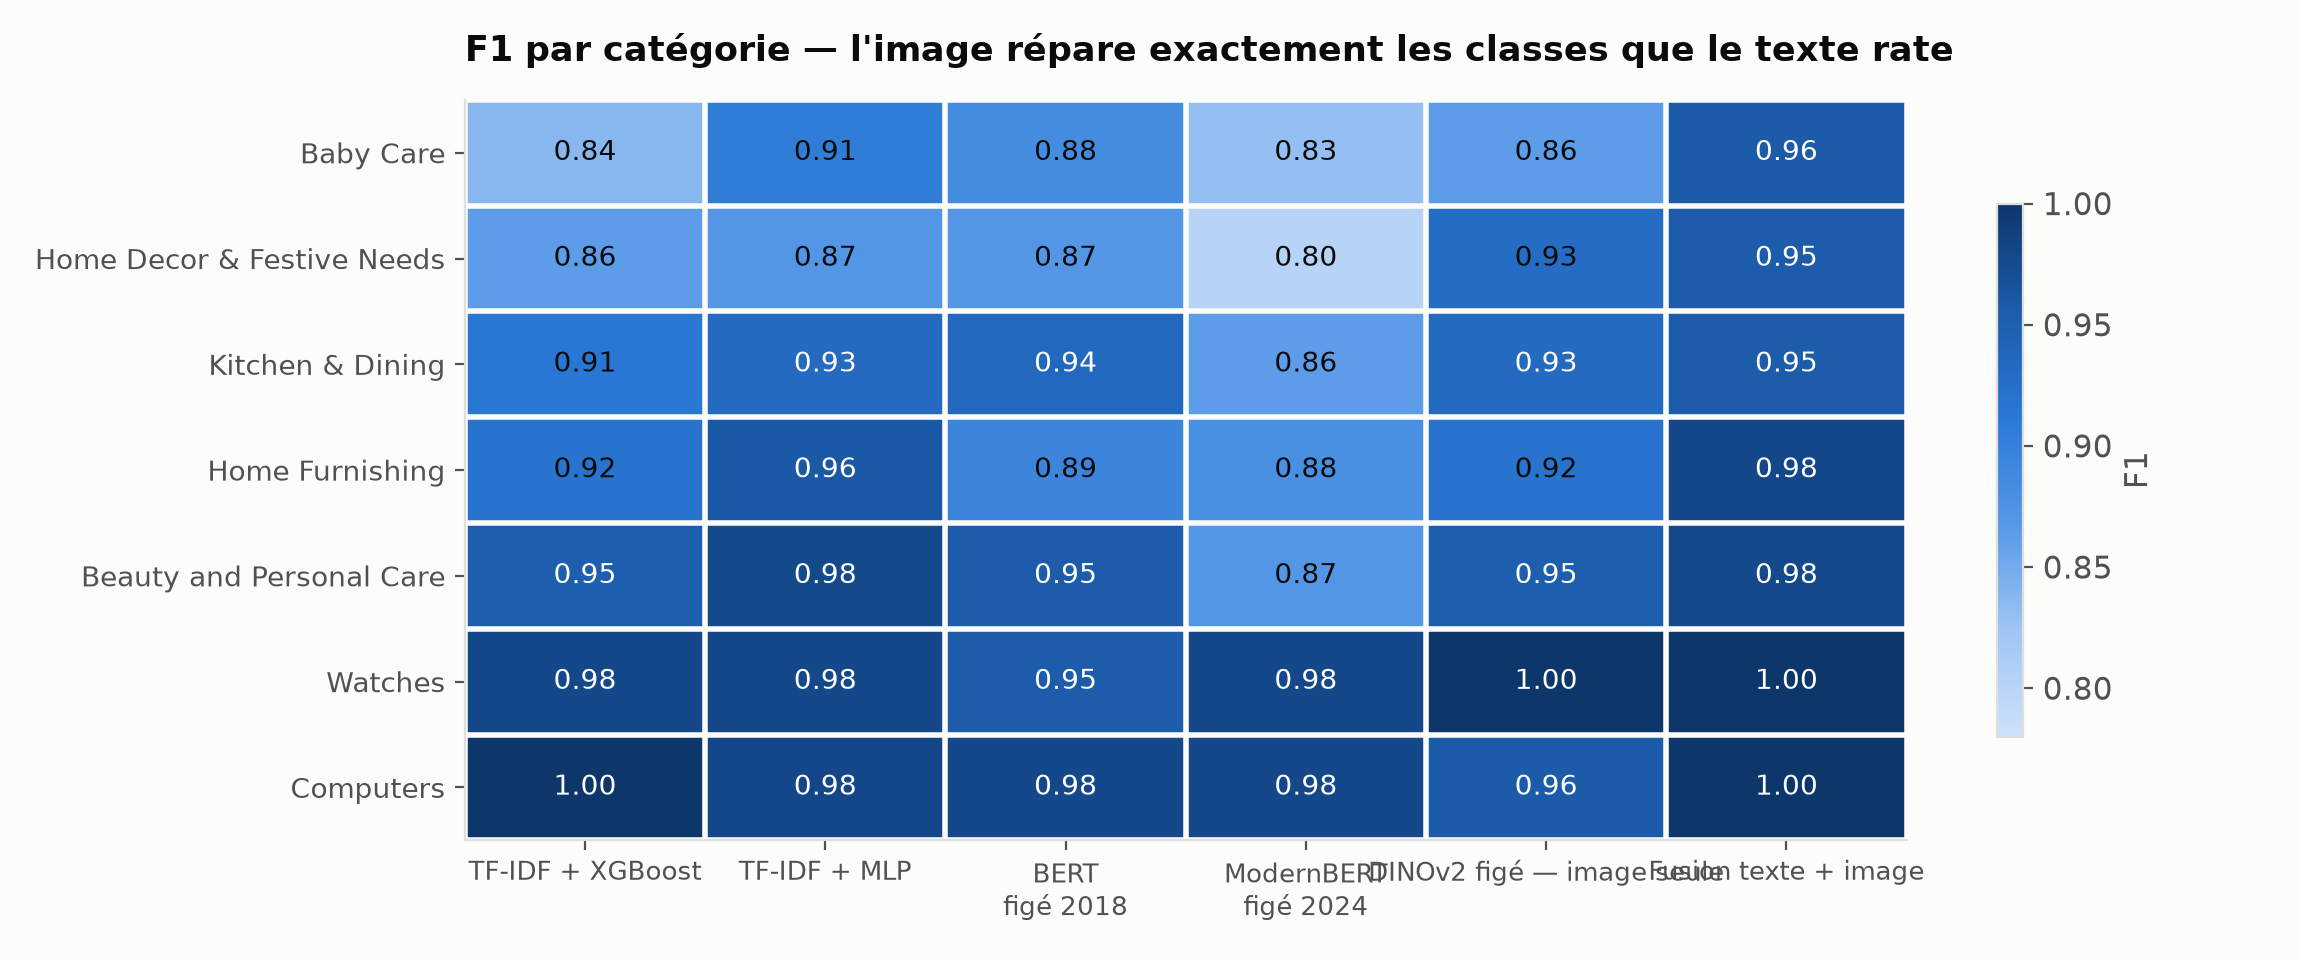

In [5]:
display(Img(str(RAPPORTS / "fig2_f1_par_classe.png"), width=1050))

La seconde figure porte le résultat le plus utile du projet : **les colonnes texte et la colonne
image ne sont pas faibles aux mêmes endroits.** *Home Decor* est la pire ligne côté texte et une des
meilleures côté image ; la colonne fusion en récolte le bénéfice.

C'est aussi ce qui justifie d'avoir gardé la F1 **par classe** plutôt que la seule moyenne : une
moyenne n'aurait jamais montré cette complémentarité.

## 3 · Ce que chaque approche achète

In [6]:
synthese = pd.DataFrame(
    [
        [
            "Fusion texte + image",
            "La classe faible passe de 0,870 à 0,955",
            "Deux chaînes ; dépend de la photographie",
            "Retenu",
        ],
        [
            "TF-IDF + MLP",
            "Quasi gratuit, lisible terme à terme",
            "Plafonne sur les catégories domestiques",
            "Repli sans photographie",
        ],
        [
            "DINOv2 figé — image seule",
            "Bat tous les encodeurs de texte figés",
            "Aveugle à la marque et aux dimensions",
            "Brique de la fusion",
        ],
        [
            "BERT figé (2018)",
            "Représentation contextuelle",
            "Aussi bon que TF-IDF pour 370× le coût",
            "Écarté",
        ],
        ["TF-IDF + XGBoost", "Le plus léger : 2,6 Mo", "Classe la plus faible à 0,837", "Écarté"],
        [
            "ModernBERT figé (2024)",
            "Architecture la plus récente",
            "Le seul sous le seuil métier",
            "Écarté",
        ],
    ],
    columns=["Approche", "Ce qu'elle apporte", "Sa limite", "Décision"],
)
synthese.style.hide(axis="index")

Approche,Ce qu'elle apporte,Sa limite,Décision
Fusion texte + image,"La classe faible passe de 0,870 à 0,955",Deux chaînes ; dépend de la photographie,Retenu
TF-IDF + MLP,"Quasi gratuit, lisible terme à terme",Plafonne sur les catégories domestiques,Repli sans photographie
DINOv2 figé — image seule,Bat tous les encodeurs de texte figés,Aveugle à la marque et aux dimensions,Brique de la fusion
BERT figé (2018),Représentation contextuelle,Aussi bon que TF-IDF pour 370× le coût,Écarté
TF-IDF + XGBoost,"Le plus léger : 2,6 Mo","Classe la plus faible à 0,837",Écarté
ModernBERT figé (2024),Architecture la plus récente,Le seul sous le seuil métier,Écarté


> **La nuance à ne pas couper.** Les encodeurs sont utilisés **figés**, sans réglage fin. Ce qui
> est comparé, ce sont des représentations, pas des capacités de modèles. Et le verdict **dépend de
> la modalité** : DINOv2 est entraîné en auto-supervision pour produire de bonnes représentations
> figées, et il tient ses promesses ; un modèle de langage masqué dont on moyenne les tokens ne l'a
> jamais été, et il déçoit.
>
> Un BERT réglé finement renverserait probablement le classement côté texte. Cela n'a pas été fait,
> et c'est la première itération suivante.

## 4 · La recommandation

Trois décisions, dans cet ordre.

In [7]:
reco = pd.DataFrame(
    [
        [
            "R1",
            "Déployer la fusion quand une photographie existe, le texte sinon",
            "le budget de 200 ms autorise les 36 ms de l'encodage image",
        ],
        [
            "R2",
            "Fixer le seuil de confiance à 0,60 et router le reste en revue humaine",
            "83 % du volume automatisé, aucune erreur observée sur 131 articles",
        ],
        [
            "R3",
            "Régler finement un encodeur de texte avant de conclure sur les transformeurs",
            "la comparaison actuelle les désavantage, et c'est écrit",
        ],
    ],
    columns=["#", "Recommandation", "Motif"],
)
reco.style.hide(axis="index")

#,Recommandation,Motif
R1,"Déployer la fusion quand une photographie existe, le texte sinon",le budget de 200 ms autorise les 36 ms de l'encodage image
R2,"Fixer le seuil de confiance à 0,60 et router le reste en revue humaine","83 % du volume automatisé, aucune erreur observée sur 131 articles"
R3,Régler finement un encodeur de texte avant de conclure sur les transformeurs,"la comparaison actuelle les désavantage, et c'est écrit"


## Ce que le projet démontre, et ce qu'il ne démontre pas

| Démontré | Non démontré |
|---|---|
| La catégorisation atteint le seuil métier fixé d'avance | Que ce seuil soit le bon : c'est un arbitrage produit |
| Le coût varie de plusieurs centaines de fois à performance comparable | Qu'un encodeur réglé finement ne renverse pas le classement |
| L'image répare les catégories que le texte confond | Que le gain tienne sur des photographies moins soignées |
| Un seuil à 0,60 automatise 83 % du volume sans erreur observée | Que ce taux tienne hors des 131 articles testés |
| La chaîne se rejoue intégralement en une commande | Que le modèle tienne sur un catalogue actuel — le corpus date de 2016 |

**Et une limite qui domine toutes les autres :** la vérité terrain est déclarée par les vendeurs, ceux
dont on cherche à corriger les erreurs. Elle place une borne haute sur toute performance mesurable —
un modèle parfait n'aurait fait qu'apprendre à reproduire les erreurs de saisie.
